# Single-Run Evaluation Analysis

Coverage by schema for each dataset, broken down by generation model.

**Source:** `outputs/evaluation/single_run/{evaluator}/{generator}/{dataset}/evaluation.json`

In [201]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

_cwd = Path.cwd()
ROOT = _cwd if (_cwd / "pyproject.toml").exists() else _cwd.parent
SINGLE_RUN_DIR = ROOT / "outputs" / "evaluation" / "single_run"
FIGURES_DIR = ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(context="paper", style="ticks")
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [202]:
# Rename generation methods / cases for display without touching the underlying dirs.
METHOD_NAMES = {
    "baseline_no_pd": "vanilla LLM",
    "baseline": "vanilla LLM + PDH",
    "schematize": "schematize",
}
METHOD_ORDER = ["baseline_no_pd", "baseline", "schematize"]

CASE_NAMES = {
    "pl_age": "Age",
    "pl_medical_errors": "Medical errors",
    "pl_personal_rights": "Personal rights",
}


def fmt_label(name: str) -> str:
    return CASE_NAMES.get(name, name)

## Load data

In [203]:
records = []
for path in sorted(SINGLE_RUN_DIR.glob("**/evaluation.json")):
    # path: single_run/{evaluator}/{generator}/{dataset}/evaluation.json
    dataset   = path.parent.name
    generator = path.parent.parent.name
    evaluator = path.parent.parent.parent.name
    ed = json.loads(path.read_text())
    for schema in ed["evaluations"]:
        cov = []
        for expert in schema["experts"]:
            t = expert["total_questions"]
            if t:
                cov.append(expert["covered_questions"] / t)
        if cov:
            records.append({
                "evaluator":    evaluator,
                "generator":    generator,
                "dataset":      dataset,
                "schema_index": schema["schema_index"],
                "num_fields":   schema["num_fields"],
                "coverage":     float(np.mean(cov)),
            })

df = pd.DataFrame(records)
print(
    f"{len(df)} schema evaluations · "
    f"{df['dataset'].nunique()} dataset(s) · "
    f"{df['generator'].nunique()} generator model(s)"
)

189 schema evaluations · 3 dataset(s) · 7 generator model(s)


## Table — coverage by schema

In [204]:
table = (
    df[["dataset", "generator", "schema_index", "num_fields", "coverage"]]
    .sort_values(["dataset", "generator", "schema_index"])
    .reset_index(drop=True)
)
table.index += 1

# LaTeX export for paper
latex = (
    table
    .assign(
        coverage=lambda d: d["coverage"].map("{:.1%}".format),
        num_fields=lambda d: d["num_fields"].astype(int),
    )
    .rename(columns={
        "dataset": "Dataset",
        "generator": "Generator",
        "schema_index": "Schema",
        "num_fields": "Fields",
        "coverage": "Coverage",
    })
    .to_latex(index=False, column_format="llcrr")
)
out_tex = FIGURES_DIR / "single_run_coverage_table.tex"
# out_tex.write_text(latex)
# print(f"LaTeX table saved: {out_tex}")
# print(latex)

## Figure — coverage by schema

Saved: /home/asawczyn/dev/schematize/outputs/figures/single_run_coverage_by_schema.pdf


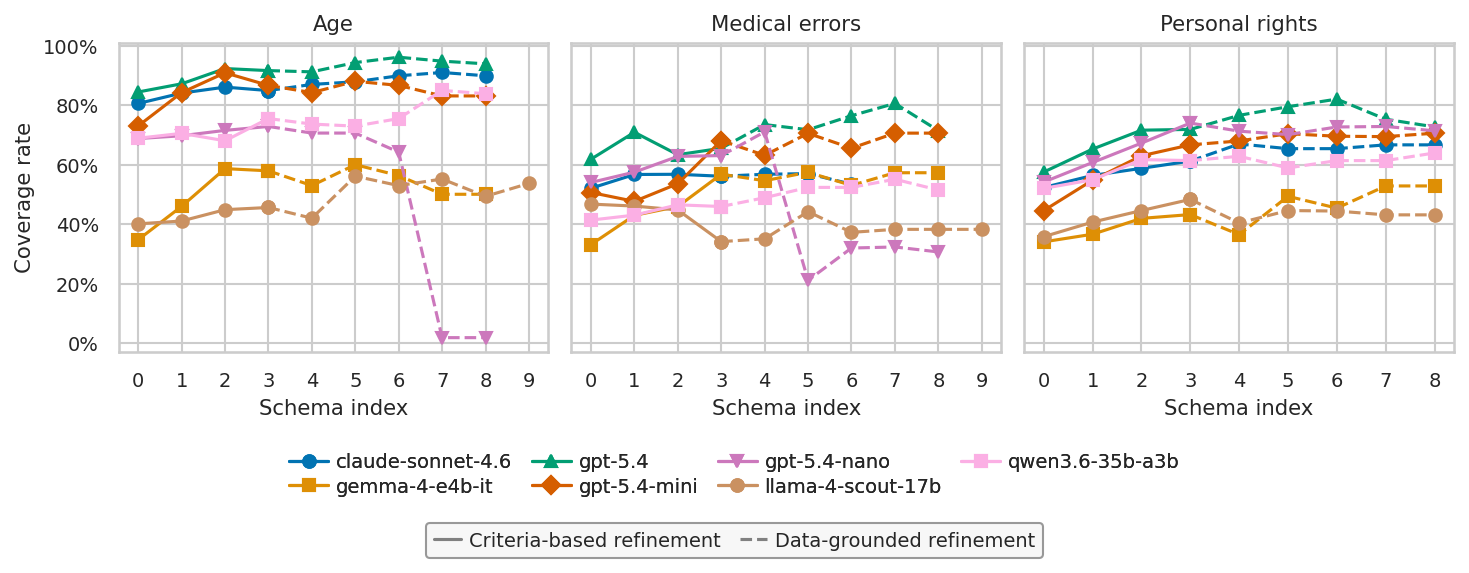

In [205]:
import matplotlib.lines as mlines

datasets   = sorted(df["dataset"].unique())
generators = sorted(df["generator"].unique())

palette    = sns.color_palette("colorblind", n_colors=len(generators))
markers    = ["o", "s", "^", "D", "v"]
color_map  = {g: palette[i % len(palette)] for i, g in enumerate(generators)}
marker_map = {g: markers[i % len(markers)] for i, g in enumerate(generators)}

# All runs have 4 criteria-based refinement schemas (indices 0-3, per the paper's
# "Schema Generation and Criteria-Based Refinement" loop) followed by data-grounded
# refinement schemas (index 4+, per "Data-Grounded Assessment and Refinement"). The
# criteria-based boundary is fixed but the number of data-grounded rounds varies per run.
CRITERIA_BASED_END = 3

col_w = 3.3
ncols = len(datasets)

sns.set_theme(style="whitegrid", font_scale=0.85)

fig, axes = plt.subplots(1, ncols, figsize=(col_w * ncols, 3.0), sharey=True)
if ncols == 1:
    axes = [axes]

for ax, dataset in zip(axes, datasets):
    sub = df[df["dataset"] == dataset]
    for gen in generators:
        g = sub[sub["generator"] == gen].sort_values("schema_index")
        kw = dict(marker=marker_map[gen], color=color_map[gen])
        ax.plot(g[g["schema_index"] <= CRITERIA_BASED_END]["schema_index"],
                g[g["schema_index"] <= CRITERIA_BASED_END]["coverage"],
                linestyle="-", label=gen, **kw)
        ax.plot(g[g["schema_index"] >= CRITERIA_BASED_END]["schema_index"],
                g[g["schema_index"] >= CRITERIA_BASED_END]["coverage"],
                linestyle="--", label="_nolegend_", **kw)

    ax.set_title(fmt_label(dataset))
    ax.set_xlabel("Schema index")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

axes[0].set_ylabel("Coverage rate")

gen_handles, gen_labels = axes[0].get_legend_handles_labels()
stage_handles = [
    mlines.Line2D([], [], color="gray", linestyle="-",  label="Criteria-based refinement"),
    mlines.Line2D([], [], color="gray", linestyle="--", label="Data-grounded refinement"),
]

gen_legend = fig.legend(
    gen_handles,
    gen_labels,
    loc="lower center",
    ncol=(len(generators) + 1) // 2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.16),
    handletextpad=0.4,
    columnspacing=1.0,
    labelspacing=0.3,
)
fig.add_artist(gen_legend)
fig.legend(
    stage_handles,
    [h.get_label() for h in stage_handles],
    loc="lower center",
    ncol=2,
    frameon=True,
    fancybox=True,
    facecolor="whitesmoke",
    edgecolor="gray",
    bbox_to_anchor=(0.5, -0.28),
    handlelength=1.4,
    handletextpad=0.4,
    columnspacing=1.0,
    borderpad=0.4,
)
fig.tight_layout()

out_pdf = FIGURES_DIR / "single_run_coverage_by_schema.pdf"
out_png = FIGURES_DIR / "single_run_coverage_by_schema.png"
fig.savefig(out_pdf, bbox_inches="tight")
fig.savefig(out_png, bbox_inches="tight")
print(f"Saved: {out_pdf}")
plt.show()

## Tables — final coverage (last schema)

In [206]:
BASELINE_EVAL_DIRS = {
    "baseline": ROOT / "outputs" / "baseline_evaluation",
    "baseline_no_pd": ROOT / "outputs" / "baseline_no_pd_evaluation",
}

baseline_records = []
for method, eval_dir in BASELINE_EVAL_DIRS.items():
    for path in sorted(eval_dir.glob("**/evaluation.json")):
        # path: {baseline_evaluation}/{evaluator}/{generator}/{dataset}/evaluation.json
        dataset   = path.parent.name
        generator = path.parent.parent.name
        evaluator = path.parent.parent.parent.name
        ed = json.loads(path.read_text())
        for schema in ed["evaluations"]:
            cov = []
            for expert in schema["experts"]:
                t = expert["total_questions"]
                if t:
                    cov.append(expert["covered_questions"] / t)
            if cov:
                baseline_records.append({
                    "method":     method,
                    "evaluator":  evaluator,
                    "generator":  generator,
                    "dataset":    dataset,
                    "coverage":   float(np.mean(cov)),
                })

baseline_df = pd.DataFrame(baseline_records)
print(f"{len(baseline_df)} baseline schema evaluations · {baseline_df['generator'].nunique()} generator(s)")

42 baseline schema evaluations · 7 generator(s)


In [207]:
last_idx = df.groupby(["evaluator", "generator", "dataset"])["schema_index"].transform("max")
final_df = df[df["schema_index"] == last_idx].assign(method="schematize")

combined_df = pd.concat(
    [final_df[["method", "generator", "dataset", "coverage"]], baseline_df[["method", "generator", "dataset", "coverage"]]],
    ignore_index=True,
)

generator_order = (
    combined_df[combined_df["method"] == "schematize"]
    .groupby("generator")["coverage"].mean()
    .sort_values(ascending=False)
    .index.tolist()
)


def fmt_cell(mean, std):
    if pd.isna(mean):
        return "-"
    return f"{mean:.1%} ± {std * 100:.1f}pp" if pd.notna(std) else f"{mean:.1%}"


def format_stats(mean_df, std_df):
    return pd.DataFrame(
        {c: [fmt_cell(m, s) for m, s in zip(mean_df[c], std_df[c])] for c in mean_df.columns},
        index=mean_df.index,
    )

### Detailed (per case)

In [208]:
detail_mean = combined_df.pivot_table(index="generator", columns=["dataset", "method"], values="coverage", aggfunc="mean")

col_order = [(d, m) for d in CASE_NAMES for m in METHOD_ORDER if (d, m) in detail_mean.columns]
detail_mean = detail_mean.loc[generator_order][col_order]

detail_table = detail_mean.map(lambda x: "-" if pd.isna(x) else f"{x:.1%}")
detail_table.columns = pd.MultiIndex.from_tuples([(CASE_NAMES[d], METHOD_NAMES[m]) for d, m in col_order])
detail_table = detail_table.rename_axis("Generator")

display(detail_table)

print(detail_table.rename_axis([None, None], axis=1).to_latex(column_format="l" + "c" * len(detail_table.columns)))

Age                              Medical errors  \
                  vanilla LLM vanilla LLM + PDH schematize    vanilla LLM   
Generator                                                                   
gpt-5.4                 49.0%             87.0%      94.0%          25.9%   
gpt-5.4-mini            38.0%             72.7%      83.2%          23.9%   
claude-sonnet-4.6       49.5%             74.9%      89.9%          29.7%   
qwen3.6-35b-a3b         27.9%             54.5%      83.9%          20.2%   
gemma-4-e4b-it           0.0%             55.0%      50.1%           3.4%   
llama-4-scout-17b       25.0%             50.1%      53.7%           9.2%   
gpt-5.4-nano            41.2%             71.5%       1.9%          20.0%   

                                               Personal rights  \
                  vanilla LLM + PDH schematize     vanilla LLM   
Generator                                                        
gpt-5.4                       53.4%      71.5%           33.9%   
gpt-5.4-mini                  47.9%      70.6%           33.3%   
claude-sonnet-4.6             50.1%      53.5%           32.1%   
qwen3.6-35b-a3b               50.1%      51.5%           37.5%   
gemma-4-e4b-it                26.9%      57.3%            7.9%   
llama-4-scout-17b             32.7%      38.3%           48.8%   
gpt-5.4-nano                  52.3%      30.7%            5.5%   

                                                
                  vanilla LLM + PDH schematize  
Generator                                       
gpt-5.4                       52.5%      72.8%  
gpt-5.4-mini                  46.0%      70.6%  
claude-sonnet-4.6             56.4%      66.7%  
qwen3.6-35b-a3b               50.2%      64.0%  
gemma-4-e4b-it                32.8%      52.9%  
llama-4-scout-17b             43.2%      43.2%  
gpt-5.4-nano                  55.6%      71.4%

\begin{tabular}{lccccccccc}
\toprule
 & \multicolumn{3}{r}{Age} & \multicolumn{3}{r}{Medical errors} & \multicolumn{3}{r}{Personal rights} \\
 & vanilla LLM & vanilla LLM + PDH & schematize & vanilla LLM & vanilla LLM + PDH & schematize & vanilla LLM & vanilla LLM + PDH & schematize \\
Generator &  &  &  &  &  &  &  &  &  \\
\midrule
gpt-5.4 & 49.0% & 87.0% & 94.0% & 25.9% & 53.4% & 71.5% & 33.9% & 52.5% & 72.8% \\
gpt-5.4-mini & 38.0% & 72.7% & 83.2% & 23.9% & 47.9% & 70.6% & 33.3% & 46.0% & 70.6% \\
claude-sonnet-4.6 & 49.5% & 74.9% & 89.9% & 29.7% & 50.1% & 53.5% & 32.1% & 56.4% & 66.7% \\
qwen3.6-35b-a3b & 27.9% & 54.5% & 83.9% & 20.2% & 50.1% & 51.5% & 37.5% & 50.2% & 64.0% \\
gemma-4-e4b-it & 0.0% & 55.0% & 50.1% & 3.4% & 26.9% & 57.3% & 7.9% & 32.8% & 52.9% \\
llama-4-scout-17b & 25.0% & 50.1% & 53.7% & 9.2% & 32.7% & 38.3% & 48.8% & 43.2% & 43.2% \\
gpt-5.4-nano & 41.2% & 71.5% & 1.9% & 20.0% & 52.3% & 30.7% & 5.5% & 55.6% & 71.4% \\
\bottomrule
\end{tabular}



### Summary (avg)

In [209]:
# Avg / std computed across the 3 cases (each case contributes one coverage value per generator/method).
per_case = combined_df.pivot_table(index=["generator", "method"], columns="dataset", values="coverage")
summary_mean = per_case.mean(axis=1).unstack("method")
summary_std = per_case.std(axis=1).unstack("method")

method_cols = [m for m in METHOD_ORDER if m in summary_mean.columns]
summary_mean = summary_mean.loc[generator_order][method_cols]
summary_std = summary_std.loc[generator_order][method_cols]

summary_table = format_stats(summary_mean, summary_std)
summary_table.columns = [METHOD_NAMES[m] for m in method_cols]
summary_table = summary_table.rename_axis("Generator")

display(summary_table)

print(summary_table.to_latex(column_format="l" + "c" * len(summary_table.columns)))

,vanilla LLM,vanilla LLM + PDH,schematize
Generator,,,
gpt-5.4,36.3% ± 11.7pp,64.3% ± 19.7pp,79.4% ± 12.6pp
gpt-5.4-mini,31.7% ± 7.2pp,55.5% ± 14.9pp,74.8% ± 7.2pp
claude-sonnet-4.6,37.1% ± 10.8pp,60.5% ± 12.9pp,70.0% ± 18.5pp
qwen3.6-35b-a3b,28.5% ± 8.7pp,51.6% ± 2.5pp,66.5% ± 16.3pp
gemma-4-e4b-it,3.8% ± 4.0pp,38.2% ± 14.8pp,53.4% ± 3.7pp
llama-4-scout-17b,27.7% ± 20.0pp,42.0% ± 8.8pp,45.1% ± 7.9pp
gpt-5.4-nano,22.2% ± 18.0pp,59.8% ± 10.3pp,34.7% ± 35.0pp


\begin{tabular}{lccc}
\toprule
 & vanilla LLM & vanilla LLM + PDH & schematize \\
Generator &  &  &  \\
\midrule
gpt-5.4 & 36.3% ± 11.7pp & 64.3% ± 19.7pp & 79.4% ± 12.6pp \\
gpt-5.4-mini & 31.7% ± 7.2pp & 55.5% ± 14.9pp & 74.8% ± 7.2pp \\
claude-sonnet-4.6 & 37.1% ± 10.8pp & 60.5% ± 12.9pp & 70.0% ± 18.5pp \\
qwen3.6-35b-a3b & 28.5% ± 8.7pp & 51.6% ± 2.5pp & 66.5% ± 16.3pp \\
gemma-4-e4b-it & 3.8% ± 4.0pp & 38.2% ± 14.8pp & 53.4% ± 3.7pp \\
llama-4-scout-17b & 27.7% ± 20.0pp & 42.0% ± 8.8pp & 45.1% ± 7.9pp \\
gpt-5.4-nano & 22.2% ± 18.0pp & 59.8% ± 10.3pp & 34.7% ± 35.0pp \\
\bottomrule
\end{tabular}



## Figure — coverage by method (bar plots)

/tmp/ipykernel_330204/1254877230.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([wrap_label(g) for g in generator_order])


Saved: /home/asawczyn/dev/schematize/outputs/figures/coverage_by_method_bars.pdf


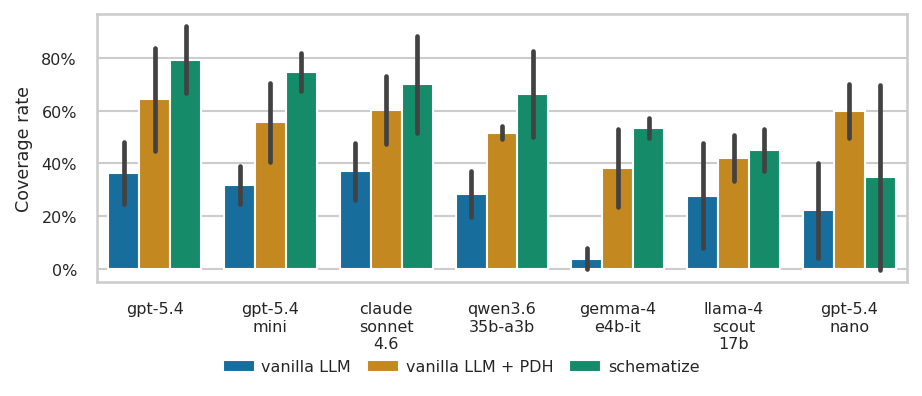

In [210]:
def wrap_label(name: str, max_len: int = 8) -> str:
    parts = name.split("-")
    lines, cur = [], ""
    for p in parts:
        if cur and len(cur) + 1 + len(p) > max_len:
            lines.append(cur)
            cur = p
        else:
            cur = f"{cur}-{p}" if cur else p
    lines.append(cur)
    return "\n".join(lines)


plot_df = combined_df.assign(Method=combined_df["method"].map(METHOD_NAMES))
methods = [m for m in METHOD_ORDER if m in combined_df["method"].unique()]
hue_order = [METHOD_NAMES[m] for m in methods]
palette = sns.color_palette("colorblind", n_colors=len(hue_order))

sns.set_theme(style="whitegrid", font_scale=0.70)
fig, ax = plt.subplots(figsize=(0.6 * len(generator_order) + 2, 2.5))
sns.barplot(
    data=plot_df, x="generator", y="coverage", hue="Method",
    order=generator_order, hue_order=hue_order, errorbar="sd",
    palette=palette, ax=ax,
)
ax.set_xticklabels([wrap_label(g) for g in generator_order])
ax.set_xlabel("")
ax.set_ylabel("Coverage rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

handles, labels = ax.get_legend_handles_labels()
ax.get_legend().remove()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=len(hue_order),
    frameon=False,
    bbox_to_anchor=(0.5, -0.05),
    handletextpad=0.4,
    columnspacing=1.0,
    labelspacing=0.3,
)
fig.tight_layout()

out_pdf = FIGURES_DIR / "coverage_by_method_bars.pdf"
out_png = FIGURES_DIR / "coverage_by_method_bars.png"
fig.savefig(out_pdf, bbox_inches="tight")
fig.savefig(out_png, bbox_inches="tight")
print(f"Saved: {out_pdf}")
plt.show()

## Table — cost analysis per generation

In [211]:
COST_DIRS = {
    "schematize":     ROOT / "outputs" / "generated_schemas",
    "baseline":       ROOT / "outputs" / "baseline",
    "baseline_no_pd": ROOT / "outputs" / "baseline_no_pd",
}

# Price per 1M tokens (input, cached_input, output) — short context
# llama, qwen, gemma pricing taken from https://pricepertoken.com/
PRICING = {
    "gpt-5.4":           (2.50,  0.250, 15.00),
    "gpt-5.4-mini":      (0.75,  0.075,  4.50),
    "gpt-5.4-nano":      (0.20,  0.020,  1.25),
    "claude-sonnet-4.6": (3.00,  0.300, 15.00),
    "llama-4-scout-17b": (0.10,  0.10,   0.30),
    "qwen3.6-35b-a3b":   (0.14,  0.14,   1.00),
    "gemma-4-e4b-it":    (0.20,  0.20,   0.10),
}

cost_records = []
for method, base_dir in COST_DIRS.items():
    for p in sorted(base_dir.glob("*/*/state.json")):
        generator = p.parent.parent.name
        dataset   = p.parent.name
        state     = json.loads(p.read_text())
        usage     = state.get("token_usage", [])
        in_tok    = sum(u["input_tokens"]  for u in usage)
        out_tok   = sum(u["output_tokens"] for u in usage)
        cache_tok = sum(u.get("input_token_details", {}).get("cache_read", 0) for u in usage)
        price     = PRICING.get(generator)
        if price and usage:
            p_in, p_cache, p_out = price
            cost = ((in_tok - cache_tok) * p_in + cache_tok * p_cache + out_tok * p_out) / 1e6
        else:
            cost = None
        cost_records.append({
            "method":    method,
            "generator": generator,
            "dataset":   dataset,
            "cost_usd":  cost,
        })

cost_df = pd.DataFrame(cost_records)

rate_df = (
    combined_df
    .merge(cost_df, on=["method", "generator", "dataset"])
    .assign(rate=lambda d: d["coverage"] / d["cost_usd"])
)


def pivot_stats_table(data, value_col, fmt):
    mean = data.pivot_table(index="generator", columns="method", values=value_col, aggfunc="mean")
    std  = data.pivot_table(index="generator", columns="method", values=value_col, aggfunc="std")
    method_cols = [m for m in METHOD_ORDER if m in mean.columns]
    order = [g for g in generator_order if g in mean.index]
    mean, std = mean.loc[order, method_cols], std.loc[order, method_cols]
    table = pd.DataFrame(
        {c: [fmt(m, s) for m, s in zip(mean[c], std[c])] for c in mean.columns},
        index=mean.index,
    )
    table.columns = [METHOD_NAMES[m] for m in method_cols]
    return table.rename_axis("Generator")


cost_table = pivot_stats_table(
    cost_df, "cost_usd", lambda m, s: f"${m:.3f} ± {s:.3f}" if pd.notna(m) else "-"
)
rate_table = pivot_stats_table(
    rate_df, "rate", lambda m, s: f"{m:.2f} ± {s:.2f}" if pd.notna(m) else "-"
)

print("Cost (USD)")
display(cost_table)
print(cost_table.to_latex(column_format="l" + "c" * len(cost_table.columns)))

print("Rate (coverage / USD)")
display(rate_table)
print(rate_table.to_latex(column_format="l" + "c" * len(rate_table.columns)))

Cost (USD)


,vanilla LLM,vanilla LLM + PDH,schematize
Generator,,,
gpt-5.4,$0.024 ± 0.008,$0.041 ± 0.006,$3.785 ± 0.312
gpt-5.4-mini,$0.005 ± 0.000,$0.008 ± 0.001,$0.828 ± 0.059
claude-sonnet-4.6,$0.027 ± 0.006,$0.039 ± 0.004,$3.057 ± 0.510
qwen3.6-35b-a3b,$0.005 ± 0.001,$0.006 ± 0.001,$0.183 ± 0.010
gemma-4-e4b-it,$0.000 ± 0.000,$0.000 ± 0.000,$0.041 ± 0.001
llama-4-scout-17b,$0.000 ± 0.000,$0.000 ± 0.000,$0.023 ± 0.002
gpt-5.4-nano,$0.002 ± 0.001,$0.003 ± 0.000,$0.234 ± 0.015


\begin{tabular}{lccc}
\toprule
 & vanilla LLM & vanilla LLM + PDH & schematize \\
Generator &  &  &  \\
\midrule
gpt-5.4 & $0.024 ± 0.008 & $0.041 ± 0.006 & $3.785 ± 0.312 \\
gpt-5.4-mini & $0.005 ± 0.000 & $0.008 ± 0.001 & $0.828 ± 0.059 \\
claude-sonnet-4.6 & $0.027 ± 0.006 & $0.039 ± 0.004 & $3.057 ± 0.510 \\
qwen3.6-35b-a3b & $0.005 ± 0.001 & $0.006 ± 0.001 & $0.183 ± 0.010 \\
gemma-4-e4b-it & $0.000 ± 0.000 & $0.000 ± 0.000 & $0.041 ± 0.001 \\
llama-4-scout-17b & $0.000 ± 0.000 & $0.000 ± 0.000 & $0.023 ± 0.002 \\
gpt-5.4-nano & $0.002 ± 0.001 & $0.003 ± 0.000 & $0.234 ± 0.015 \\
\bottomrule
\end{tabular}

Rate (coverage / USD)


,vanilla LLM,vanilla LLM + PDH,schematize
Generator,,,
gpt-5.4,16.68 ± 8.27,15.77 ± 4.34,0.21 ± 0.05
gpt-5.4-mini,59.72 ± 16.43,71.97 ± 9.80,0.90 ± 0.06
claude-sonnet-4.6,14.67 ± 6.66,15.88 ± 4.42,0.23 ± 0.02
qwen3.6-35b-a3b,62.53 ± 23.96,83.88 ± 5.71,3.62 ± 0.77
gemma-4-e4b-it,235.69 ± 249.55,781.02 ± 322.87,13.19 ± 1.07
llama-4-scout-17b,1460.08 ± 1140.64,1168.13 ± 258.31,19.89 ± 5.44
gpt-5.4-nano,124.90 ± 68.85,198.97 ± 33.63,1.46 ± 1.51


\begin{tabular}{lccc}
\toprule
 & vanilla LLM & vanilla LLM + PDH & schematize \\
Generator &  &  &  \\
\midrule
gpt-5.4 & 16.68 ± 8.27 & 15.77 ± 4.34 & 0.21 ± 0.05 \\
gpt-5.4-mini & 59.72 ± 16.43 & 71.97 ± 9.80 & 0.90 ± 0.06 \\
claude-sonnet-4.6 & 14.67 ± 6.66 & 15.88 ± 4.42 & 0.23 ± 0.02 \\
qwen3.6-35b-a3b & 62.53 ± 23.96 & 83.88 ± 5.71 & 3.62 ± 0.77 \\
gemma-4-e4b-it & 235.69 ± 249.55 & 781.02 ± 322.87 & 13.19 ± 1.07 \\
llama-4-scout-17b & 1460.08 ± 1140.64 & 1168.13 ± 258.31 & 19.89 ± 5.44 \\
gpt-5.4-nano & 124.90 ± 68.85 & 198.97 ± 33.63 & 1.46 ± 1.51 \\
\bottomrule
\end{tabular}



In [212]:
# Todo: tables with stats:
#  num of fields, distribution of types
# cost per generation